# _4.2.5. (multi-class) classification using XGB_

Main topics of the current notebook is to focus on applying XGB to the problem of anomaly detection, i.e., categorizing anomalies into distinct classes : reorder, duplicate, corrupt anomaly or simply normal case.

#### _a. Load Data_

Recall, the dataset was already cleaned and normalized _(using StandardScaler)_. Columns with zero or near-zero variance deleted.

In [1]:
from xgboost import XGBClassifier

import seaborn as sns 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import os
import torch
import time 

from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import RandomizedSearchCV, train_test_split

from scipy.stats import uniform, randint

from skopt import BayesSearchCV

%matplotlib inline

In [2]:
scaled_new_dataset = "data/scaled_new_godash_dataset.csv"
scaled_new_df = pd.read_csv(scaled_new_dataset, index_col=0)

scaled_new_df.head(5)

,Seg_id,Arr_time,Del_Time,Stall_Dur,Rep_Level,Del_Rate,Act_Rate,Byte_Size,Buff_Level,Width,...,Yu,algo,nb_nodes,mos,MOS,mos_label,anomaly,level,tag2,tag
0,-1.697807,-0.445033,-0.204334,-0.164204,-1.294465,-1.160341,-1.160370,-1.160361,-0.833377,-1.247338,...,0.360347,-1.462647,0.524565,-1.043858,-0.045817,bad,0,-1.083746,False,0
1,-1.640070,-0.441006,-0.198458,-0.164204,-1.294465,-0.396335,-1.008632,-1.008502,-0.575036,-1.247338,...,0.360347,-1.462647,0.524565,-1.114816,-0.045817,bad,0,-1.083746,False,0
2,-1.582333,-0.436192,-0.186196,-0.164204,-1.108483,0.193475,-0.664977,-0.665158,-0.460461,-0.978685,...,0.367256,-1.462647,0.524565,-0.964049,-0.045817,bad,0,-1.083746,False,0
3,-1.524596,-0.430804,-0.169590,-0.164204,-0.826439,0.384235,-0.245217,-0.244990,-0.363067,-0.799582,...,0.378520,-1.462647,0.524565,-0.956997,-0.045817,bad,0,-1.083746,False,0
4,-1.466860,-0.425614,-0.169846,-0.164204,-0.422082,0.397624,-0.242853,-0.242699,-0.259859,-0.665255,...,0.394329,-1.462647,0.524565,-0.943719,-0.045817,bad,0,-1.083746,False,0


In [3]:
# Recall, all the following have been deleted --> ['Seg_Dur', 'Codec', 'FPS', 'Protocol']
all_features = ['Seg_id', 'Arr_time', 'Del_Time', 'Stall_Dur', 'Rep_Level', 'Del_Rate',
                'Act_Rate', 'Byte_Size', 'Buff_Level', 'Width',
                'Height', 'Play_Pos', 'RTT', 'P.1203', 'Clae',
                'Duanmu', 'Yin', 'Yu', 'algo', 'nb_nodes', 'mos', 'MOS', 'mos_label', 
                'anomaly', 'level', 'tag2', 'tag']

new_df = scaled_new_df [all_features]
selected_features = all_features[:-4]
target = "anomaly"

In [4]:
dataset_name = 'new_godash_dataset'
train = new_df.copy()
n_total = len(train)
print ("n_total = ", n_total)
print ("nb features =", len(train.columns))
print ("nan values =", train.isna().sum().sum())

n_total =  85596
nb features = 27
nan values = 0


#### _b. Label Encode target y_

The basic Idea here is to see the problem as a binary classification problem. 

The population is already devided into different anomalies tag using "anomaly" column.

In [5]:
train[target].value_counts(normalize=True)

0    0.253049
1    0.252348
2    0.252348
3    0.242254
Name: anomaly, dtype: float64

In [6]:
# {'normal': 0, 'reorder': 1, 'duplicate': 2, 'corrupt': 3}
train["anomaly"].value_counts()

0    21660
1    21600
2    21600
3    20736
Name: anomaly, dtype: int64

#### _c. Split_

In [7]:
train_val_indices, test_indices = train_test_split(range(n_total), test_size=0.2, random_state=0)
train_indices, valid_indices =    train_test_split(train_val_indices, test_size=0.2 / 0.6, random_state=0)

# This is a generic pipeline but actually no categorical features are available for this dataset
unused_feat = ["mos_label", 'tag', 'level', 'anomaly']
features = [ col for col in selected_features if col not in unused_feat+[target]] 

print ("len(features) =", len(features))

if os.getenv("CI", False):
# Take only a subsample to run CI
    X_train = train[features].values[train_indices][:1000,:]
    y_train = train[target].values[train_indices][:1000]
else:
    X_train = train[features].values[train_indices]
    y_train = train[target].values[train_indices]

X_valid = train[features].values[valid_indices]
y_valid = train[target].values[valid_indices]

X_test = train[features].values[test_indices]
y_test = train[target].values[test_indices]

print ("shape(X_train) :", X_train.shape)
print ("shape(y_train) :", y_train.shape)

len(features) = 22
shape(X_train) : (45650, 22)
shape(y_train) : (45650,)


#### _d. Check CUDA support_

In [8]:
print ("Is CUDA available :", torch.cuda.is_available())
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print ("Device :", DEVICE)

Is CUDA available : True
Device : cuda


### _e.  Extreme Gradient Boosting (XGB)_

- _**XGB**_ is an advanced and highly efficient implementation of _**gradient boosting**_. It includes several enhancements such as regularization, parallel processing, and a tree-pruning algorithm to prevent overfitting which make it a popular choice in numerous ML competitions.

<br>

<div style="float: center;"><img  src="https://miro.medium.com/v2/resize:fit:720/format:webp/0*g3xZsAFWEo4FpMG3.png"  alt="binary classification"  width="300"/>
</div>

</br>


We use _**DMLC/XGBoost**_, one of the most popular ML library for gradient boosting. It has grown from a research project incubated in academia to _the most widely used gradient boosting framework in production_ environment [[about]](https://opencollective.com/xgboost) [[package]](https://pypi.org/project/xgboost/)

> pip install xgboost
>
> from xgboost import XGBClassifier

In [9]:
import xgboost
xgboost.__version__

'1.6.2'

In [10]:
n_estimators = 1000 if not os.getenv("CI", False) else 20

clf_xgb_chatgpt = XGBClassifier(
    max_depth=16,
    learning_rate=0.01,
    n_estimators=n_estimators,
    objective="multi:softmax",  # Change to "multi:softmax" for discrete output
    # objective='binary:logistic',
    booster='gbtree',
    n_jobs=-1,
    subsample=0.7,
    colsample_bytree=1,
    reg_alpha=0,
    reg_lambda=1,
    scale_pos_weight=1,
    random_state=0,
    tree_method="gpu_hist"
)

start_time = time.time()
clf_xgb_chatgpt.fit(X_train, y_train,
            eval_set=[(X_train, y_train), (X_valid, y_valid)],
            early_stopping_rounds=40,
            verbose=10)

print(f"Training completed in {(time.time()-start_time):.2f} seconds.")

[18:00:07] WARNING: C:/Users/administrator/workspace/xgboost-win64_release_1.6.0/src/learner.cc:627: 
Parameters: { "scale_pos_weight" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.




C:\Users\kabou\.conda\envs\py37\lib\site-packages\xgboost\sklearn.py:797: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  UserWarning,


[0]	validation_0-mlogloss:1.36998	validation_1-mlogloss:1.37083
[10]	validation_0-mlogloss:1.22286	validation_1-mlogloss:1.23161
[20]	validation_0-mlogloss:1.09884	validation_1-mlogloss:1.11483
[30]	validation_0-mlogloss:0.99281	validation_1-mlogloss:1.01535
[40]	validation_0-mlogloss:0.90079	validation_1-mlogloss:0.92931
[50]	validation_0-mlogloss:0.82004	validation_1-mlogloss:0.85418
[60]	validation_0-mlogloss:0.74912	validation_1-mlogloss:0.78828
[70]	validation_0-mlogloss:0.68619	validation_1-mlogloss:0.73009
[80]	validation_0-mlogloss:0.63018	validation_1-mlogloss:0.67849
[90]	validation_0-mlogloss:0.58014	validation_1-mlogloss:0.63265
[100]	validation_0-mlogloss:0.53501	validation_1-mlogloss:0.59147
[110]	validation_0-mlogloss:0.49462	validation_1-mlogloss:0.55474
[120]	validation_0-mlogloss:0.45803	validation_1-mlogloss:0.52172
[130]	validation_0-mlogloss:0.42510	validation_1-mlogloss:0.49213
[140]	validation_0-mlogloss:0.39526	validation_1-mlogloss:0.46534
[150]	validation_0-ml

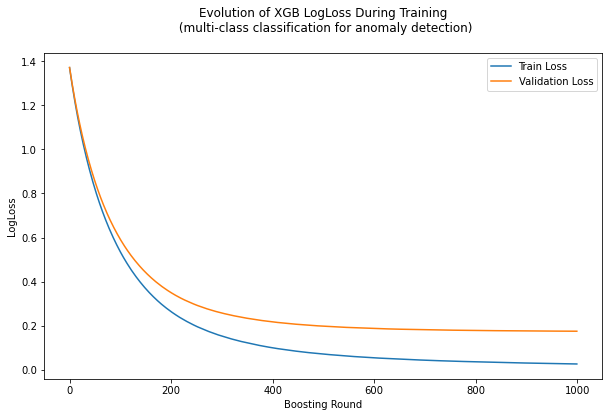

In [11]:
# Get the evaluation results
eval_results = clf_xgb_chatgpt.evals_result()

# Plot the evolution of accuracy
# train_accuracy = eval_results['train']['merror']
logloss_train = eval_results['validation_0']['mlogloss']
logloss_validation = eval_results['validation_1']['mlogloss']

plt.figure(figsize=(10, 6))
# plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(logloss_train, label='Train Loss')
plt.plot(logloss_validation, label='Validation Loss')
plt.xlabel('Boosting Round')
plt.ylabel('LogLoss')
plt.title('Evolution of XGB LogLoss During Training\n (multi-class classification for anomaly detection)\n')
plt.legend()
plt.show()

In [35]:
# Assuming clf_xgb is your trained XGBoost model
# X_valid and y_valid are your validation data
y_pred_valid = clf_xgb_chatgpt.predict(X_valid)
y_pred_train = clf_xgb_chatgpt.predict(X_train)

# Calculate accuracy
valid_accuracy = accuracy_score(y_valid, y_pred_valid)
train_accuracy = accuracy_score(y_train, y_pred_train)

print("Validation Accuracy:", round(valid_accuracy, 4))
print("Train Accuracy:", round(train_accuracy, 4))

Validation Accuracy: 0.9381
Train Accuracy: 0.9998


In [12]:
# Assuming clf_xgb is your trained XGBoost model
# X_valid and y_valid are your validation data
y_pred_valid = clf_xgb_chatgpt.predict(X_valid)
y_pred_train = clf_xgb_chatgpt.predict(X_train)

# Calculate accuracy
valid_accuracy = accuracy_score(y_valid, y_pred_valid)
train_accuracy = accuracy_score(y_train, y_pred_train)

print("Validation Accuracy:", valid_accuracy)
print("Train Accuracy:", train_accuracy)

Validation Accuracy: 0.9381407167265399
Train Accuracy: 0.9997590361445783


In [13]:
scorez = clf_xgb_chatgpt.feature_importances_

# Sort features based on their absolute coefficients
feature_importance = pd.DataFrame({'feature': features, 'score': scorez})
feature_importance = feature_importance.sort_values(by='score', ascending=False)
feature_importance['f_indice'] = feature_importance.index
feature_importance = feature_importance.reset_index().drop(["index"], axis=1)
feature_importance['rank'] = feature_importance.index+1
feature_importance.head(20)

,feature,score,f_indice,rank
0,Del_Rate,0.209440,5,1
1,RTT,0.094592,12,2
2,Del_Time,0.085556,2,3
3,P.1203,0.081564,13,4
4,nb_nodes,0.073816,19,5
5,Byte_Size,0.062958,7,6
6,Act_Rate,0.049621,6,7
7,Buff_Level,0.042769,8,8
8,Clae,0.040829,14,9
9,algo,0.039500,18,10


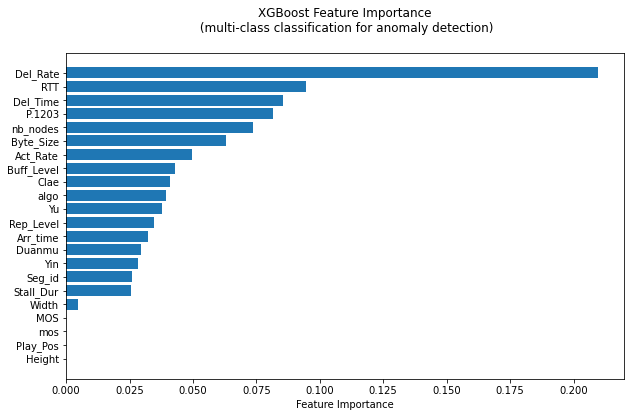

In [14]:
feature_importance = clf_xgb_chatgpt.feature_importances_

# Map feature names to importance scores
feature_names = [features[i] for i in range(X_train.shape[1])]
feature_importance_dict = dict(zip(feature_names, feature_importance))

# Sort features by importance
sorted_features = sorted(feature_importance_dict.items(), key=lambda x: x[1])


# Plot the feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_features)), [importance for feature, importance in sorted_features], align="center")
plt.yticks(range(len(sorted_features)), [feature for feature, importance in sorted_features])
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importance\n (multi-class classification for anomaly detection)\n")
plt.show()

In [15]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = clf_xgb_chatgpt.predict(X_valid)

# Create a confusion matrix
conf_matrix = confusion_matrix(y_valid, y_pred)

# Display a classification report
print("\n(XGB) Classification Report:\n(multi-class classification for anomaly detection)\n")
print(classification_report(y_valid, y_pred))


(XGB) Classification Report:
(multi-class classification for anomaly detection)

              precision    recall  f1-score   support

           0       0.93      0.96      0.95      5831
           1       0.95      0.96      0.96      5718
           2       0.90      0.92      0.91      5790
           3       0.98      0.91      0.94      5487

    accuracy                           0.94     22826
   macro avg       0.94      0.94      0.94     22826
weighted avg       0.94      0.94      0.94     22826



In [16]:
labaled_classes = ['normal','reorder', 'duplicate','corrupt']
classes = np.unique(y_train) 
print (labaled_classes)
print (classes)

['normal', 'reorder', 'duplicate', 'corrupt']
[0 1 2 3]


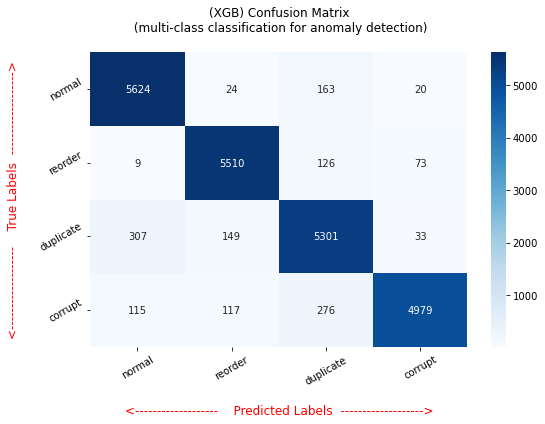

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

classes = [classe+0.5 for classe in classes]

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xticks(classes, labaled_classes, rotation=30)
plt.yticks(classes, labaled_classes, rotation=30)
plt.xlabel("<-------------------    Predicted Labels  ------------------->", fontsize=12, color="red", labelpad=18)
plt.ylabel("<-------------------    True Labels  ------------------->",  fontsize=12, color="red", labelpad=18)
plt.title("(XGB) Confusion Matrix\n (multi-class classification for anomaly detection)\n")
plt.tight_layout()
plt.show()

#### _Hyperparameter Tunning_

Often the general effects of hyperparameters on a model are known, but how to best set a hyperparameter and combinations of interacting hyperparameters for a given dataset is challenging [[ref]](https://machinelearningmastery.com/hyperparameter-optimization-with-random-search-and-grid-search/).

Bellow are some suggested values for XGB hyperparameters.

In [18]:
# Suggested values for hyperparameters
learning_rate_values =     [0.01, 0.1, 0.2, 0.3]
max_depth_values =         [3, 5, 7]                  
subsample_values =         [0.5, 0.7, 0.8]            
colsample_bytree_values =  [0.5, 0.7, 0.8]     
colsample_bylevel_values = [0.5, 0.7, 0.8]   
gamma_values =             [0, 0.1, 0.2, 0.5]
min_child_weight_values =  [1, 3, 5]          
reg_alpha_values =         [0.1, 0.5, 1.0]            
reg_lambda_values =        [0.1, 0.5, 1.0]           
n_estimators_values =      [50, 100, 150]          

# Objective for multi-class classification
objectivez_value = ['binary:logistic', 'multi:softmax', 'multi:softprob']  # for discrete or probability output

### _Random Search_

Let us start with random search strategy for an exploration of the hyperparameter space. 

In [19]:
start_time = time.time()

# Create an XGBoost classifier
clf_xgb = XGBClassifier(tree_method="gpu_hist", objective='multi:softmax', \
                        num_class=4, n_jobs=10, predictor='gpu_predictor')

# Define the hyperparameter search space
param_dist = {
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(3, 10),
    'subsample': uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.5, 0.5),
    'colsample_bylevel': uniform(0.5, 0.5),
    'gamma': uniform(0, 0.5),
    'min_child_weight': randint(1, 10),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 1),
    'n_estimators': randint(50, 300)
}

# Perform random search
random_search = RandomizedSearchCV(
    clf_xgb, param_distributions=param_dist, n_iter=40,
    scoring='accuracy', cv=3, verbose=1, pre_dispatch = 10
)

# Fit the model
random_search.fit(X_train, y_train)

print(f"Training completed in {(time.time()-start_time)/60:.2f} mnt.")

# Print the best hyperparameters
print("Best Hyperparameters:", random_search.best_params_)

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Training completed in 12.53 mnt.
Best Hyperparameters: {'colsample_bylevel': 0.7935447549032295, 'colsample_bytree': 0.7329690950245711, 'gamma': 0.3549383389784234, 'learning_rate': 0.19772179758565883, 'max_depth': 8, 'min_child_weight': 3, 'n_estimators': 287, 'reg_alpha': 0.8024727160138726, 'reg_lambda': 0.9564124011301848, 'subsample': 0.8756034785981661}


In [20]:
# Get the best model
best_model = random_search.best_estimator_

# Training set
training_performance = best_model.score(X_train, y_train)
print("Train Accuracy with Best Model:", training_performance)

# Evaluate the best model on your validation set
best_model_performance = best_model.score(X_valid, y_valid)
print("Validation Accuracy with Best Model:", best_model_performance)

Train Accuracy with Best Model: 0.9812486308871851
Validation Accuracy with Best Model: 0.9387978620870937


In [21]:
scorez = best_model.feature_importances_

# Sort features based on their absolute coefficients
feature_importance = pd.DataFrame({'feature': features, 'score': scorez})
feature_importance = feature_importance.sort_values(by='score', ascending=False)
feature_importance['f_indice'] = feature_importance.index
feature_importance = feature_importance.reset_index().drop(["index"], axis=1)
feature_importance['rank'] = feature_importance.index+1
feature_importance.head(20)

,feature,score,f_indice,rank
0,Del_Rate,0.123841,5,1
1,P.1203,0.118905,13,2
2,RTT,0.093939,12,3
3,Height,0.061499,10,4
4,Stall_Dur,0.054995,3,5
5,Width,0.052816,9,6
6,Yu,0.051554,17,7
7,nb_nodes,0.048629,19,8
8,Del_Time,0.046473,2,9
9,Rep_Level,0.042708,4,10


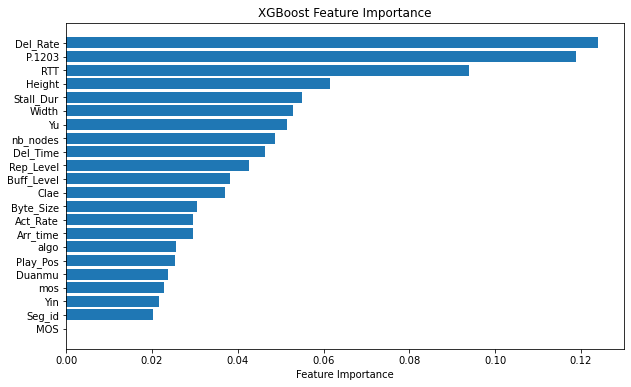

In [22]:
feature_importance = best_model.feature_importances_

# Map feature names to importance scores
feature_names = [features[i] for i in range(X_train.shape[1])]
feature_importance_dict = dict(zip(feature_names, feature_importance))

# Sort features by importance
sorted_features = sorted(feature_importance_dict.items(), key=lambda x: x[1])

# Plot the feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_features)), [importance for feature, importance in sorted_features], align="center")
plt.yticks(range(len(sorted_features)), [feature for feature, importance in sorted_features])
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importance")
plt.show()

In [23]:
y_pred = best_model.predict(X_valid)

# Create a confusion matrix
conf_matrix = confusion_matrix(y_valid, y_pred)

# Display a classification report
print("\n(XGB+Random_Grid_Search) Classification Report\n (multi-class classification for anomaly detection)\n")
print(classification_report(y_valid, y_pred))


(XGB+Random_Grid_Search) Classification Report
 (multi-class classification for anomaly detection)

              precision    recall  f1-score   support

           0       0.92      0.97      0.95      5831
           1       0.95      0.97      0.96      5718
           2       0.90      0.91      0.91      5790
           3       0.98      0.91      0.94      5487

    accuracy                           0.94     22826
   macro avg       0.94      0.94      0.94     22826
weighted avg       0.94      0.94      0.94     22826



In [24]:
labaled_classes = ['normal','reorder', 'duplicate','corrupt']
classes = np.unique(y_train) 
print (labaled_classes)
print (classes)

['normal', 'reorder', 'duplicate', 'corrupt']
[0 1 2 3]


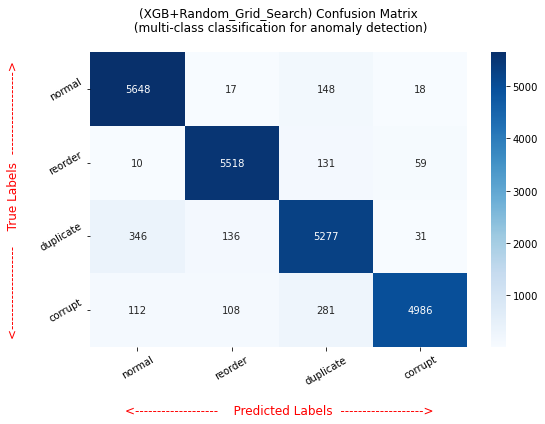

In [25]:
classes = [classe+0.5 for classe in classes]

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xticks(classes, labaled_classes, rotation=30)
plt.yticks(classes, labaled_classes, rotation=30)
plt.xlabel("<-------------------    Predicted Labels  ------------------->", fontsize=12, color="red", labelpad=18)
plt.ylabel("<-------------------    True Labels  ------------------->",  fontsize=12, color="red", labelpad=18)
plt.title("(XGB+Random_Grid_Search) Confusion Matrix\n (multi-class classification for anomaly detection)\n")
plt.tight_layout()
plt.show()

### _Bayes Search CV_

For a more _robust_ approach of _hyper-parameter optimization_, let us try _**Bayesian optimization**_. 

Bayesian Optimization finds the minimum to an objective function in large problem-spaces and is very applicable to continuous values. To do this it uses Gaussian Process regression on the objective function under the hood. In our case the objective function is to arrive at the best model output given the model-parameters that we specify [[ref]](https://towardsdatascience.com/optimizing-hyperparameters-the-right-way-3c9cafc279cc).

<br>

<div style="float: center;"><img  src="https://miro.medium.com/v2/resize:fit:1400/1*sPTZiXuWHBct_kYiD_5aYA.jpeg"  alt="Bayes Search CV"  width="400"/>
</div>

</br>



Our tool of choice is _**BayesSearchCV**_. This approach uses stepwise Bayesian Optimization to explore the most promising hyperparameters in the problem-space [[package]](https://scikit-optimize.github.io/stable/modules/generated/skopt.BayesSearchCV.html).

In [26]:
start_time = time.time()

param_space = {
    'learning_rate': (0.01, 0.3, 'log-uniform'),
    'max_depth': (3, 7),
    'subsample': (0.5, 0.8),
    'colsample_bytree': (0.5, 0.8),
    'colsample_bylevel': (0.5, 0.8),
    'gamma': (0, 0.5),
    'min_child_weight': (1, 5),
    'reg_alpha': (0.1, 1.0),
    'reg_lambda': (0.1, 1.0),
    'n_estimators': (50, 150),
}

bayes_xgb = XGBClassifier(tree_method="gpu_hist", objective='multi:softmax', \
                          num_class=4, n_jobs=10, predictor='gpu_predictor',\
                          random_state=0)

bayes_search = BayesSearchCV(
    bayes_xgb,
    param_space,
    n_iter=50,  # Adjust the number of iterations based on your computational resources
    cv=3,  # Number of cross-validation folds
    pre_dispatch = 20,  # Use all available CPU cores
    scoring='accuracy',  # Choose an appropriate metric for your problem
    random_state=0,
)

# Perform the Bayesian optimization
bayes_search.fit(X_train, y_train)

print(f"Training completed in {(time.time()-start_time)/60:.2f} mnts.")

# Get the best hyperparameters
best_params = bayes_search.best_params_
print("Best Hyperparameters:", best_params)

Training completed in 11.83 mnts.
Best Hyperparameters: OrderedDict([('colsample_bylevel', 0.8), ('colsample_bytree', 0.8), ('gamma', 0.0), ('learning_rate', 0.2413939251245332), ('max_depth', 7), ('min_child_weight', 1), ('n_estimators', 150), ('reg_alpha', 0.1), ('reg_lambda', 1.0), ('subsample', 0.8)])


In [27]:
# Evaluate the model on the validation set
validation_accuracy = bayes_search.score(X_valid, y_valid)
print("Validation Accuracy:", validation_accuracy)

# Evaluate the model on the validation set
train_accuracy = bayes_search.score(X_train, y_train)
print("train Accuracy:", train_accuracy)

Validation Accuracy: 0.938973100849908
train Accuracy: 0.9898138006571742


In [28]:
# Get the best model
bayes_best_model = bayes_search.best_estimator_

In [29]:
y_pred = bayes_best_model.predict(X_valid)

# Create a confusion matrix
bayes_conf_matrix = confusion_matrix(y_valid, y_pred)

# Display a classification report
print("\n   (XGB+Bayes_Search) Classification Report\n(multi-class classification for anomaly detection)\n")
print(classification_report(y_valid, y_pred))


   (XGB+Bayes_Search) Classification Report
(multi-class classification for anomaly detection)

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      5831
           1       0.95      0.97      0.96      5718
           2       0.90      0.91      0.91      5790
           3       0.98      0.91      0.94      5487

    accuracy                           0.94     22826
   macro avg       0.94      0.94      0.94     22826
weighted avg       0.94      0.94      0.94     22826



In [30]:
labaled_classes = ['normal','reorder', 'duplicate','corrupt']
classes = np.unique(y_train) 
print (labaled_classes)
print (classes)

['normal', 'reorder', 'duplicate', 'corrupt']
[0 1 2 3]


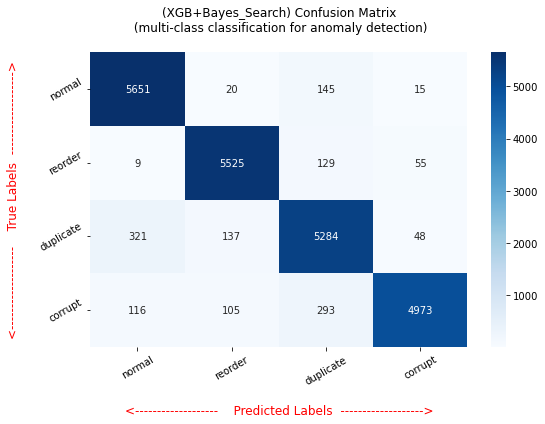

In [31]:
classes = [classe+0.5 for classe in classes]

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(bayes_conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xticks(classes, labaled_classes, rotation=30)
plt.yticks(classes, labaled_classes, rotation=30)
plt.xlabel("<-------------------    Predicted Labels  ------------------->", fontsize=12, color="red", labelpad=18)
plt.ylabel("<-------------------    True Labels  ------------------->",  fontsize=12, color="red", labelpad=18)
plt.title("(XGB+Bayes_Search) Confusion Matrix\n (multi-class classification for anomaly detection)\n")
plt.tight_layout()
plt.show()

In [32]:
scorez = bayes_best_model.feature_importances_

# Sort features based on their absolute coefficients
feature_importance = pd.DataFrame({'feature': features, 'score': scorez})
feature_importance = feature_importance.sort_values(by='score', ascending=False)
feature_importance['f_indice'] = feature_importance.index
feature_importance = feature_importance.reset_index().drop(["index"], axis=1)
feature_importance['rank'] = feature_importance.index+1
feature_importance.head(10)

,feature,score,f_indice,rank
0,P.1203,0.169183,13,1
1,Del_Rate,0.127615,5,2
2,RTT,0.087050,12,3
3,nb_nodes,0.059206,19,4
4,Act_Rate,0.048244,6,5
5,algo,0.044086,18,6
6,Del_Time,0.043397,2,7
7,Buff_Level,0.041289,8,8
8,Clae,0.039505,14,9
9,Width,0.039185,9,10


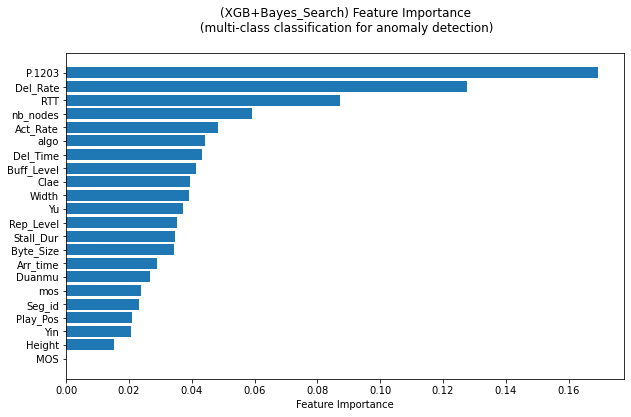

In [33]:
feature_importance = bayes_best_model.feature_importances_

# Map feature names to importance scores
feature_names = [features[i] for i in range(X_train.shape[1])]
feature_importance_dict = dict(zip(feature_names, feature_importance))

# Sort features by importance
sorted_features = sorted(feature_importance_dict.items(), key=lambda x: x[1])

# Plot the feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_features)), [importance for feature, importance in sorted_features], align="center")
plt.yticks(range(len(sorted_features)), [feature for feature, importance in sorted_features])
plt.xlabel("Feature Importance")
plt.title("(XGB+Bayes_Search) Feature Importance\n (multi-class classification for anomaly detection)\n")
plt.show()